NBSS slope  : -0.887
centroid    : +1.266
slope_2pt   : +0.340
Pico/Nano/Micro biomass: [0.1960884 0.457203  0.9382748]
Saved figure to: fig_baseline_FN8_with_slope.png


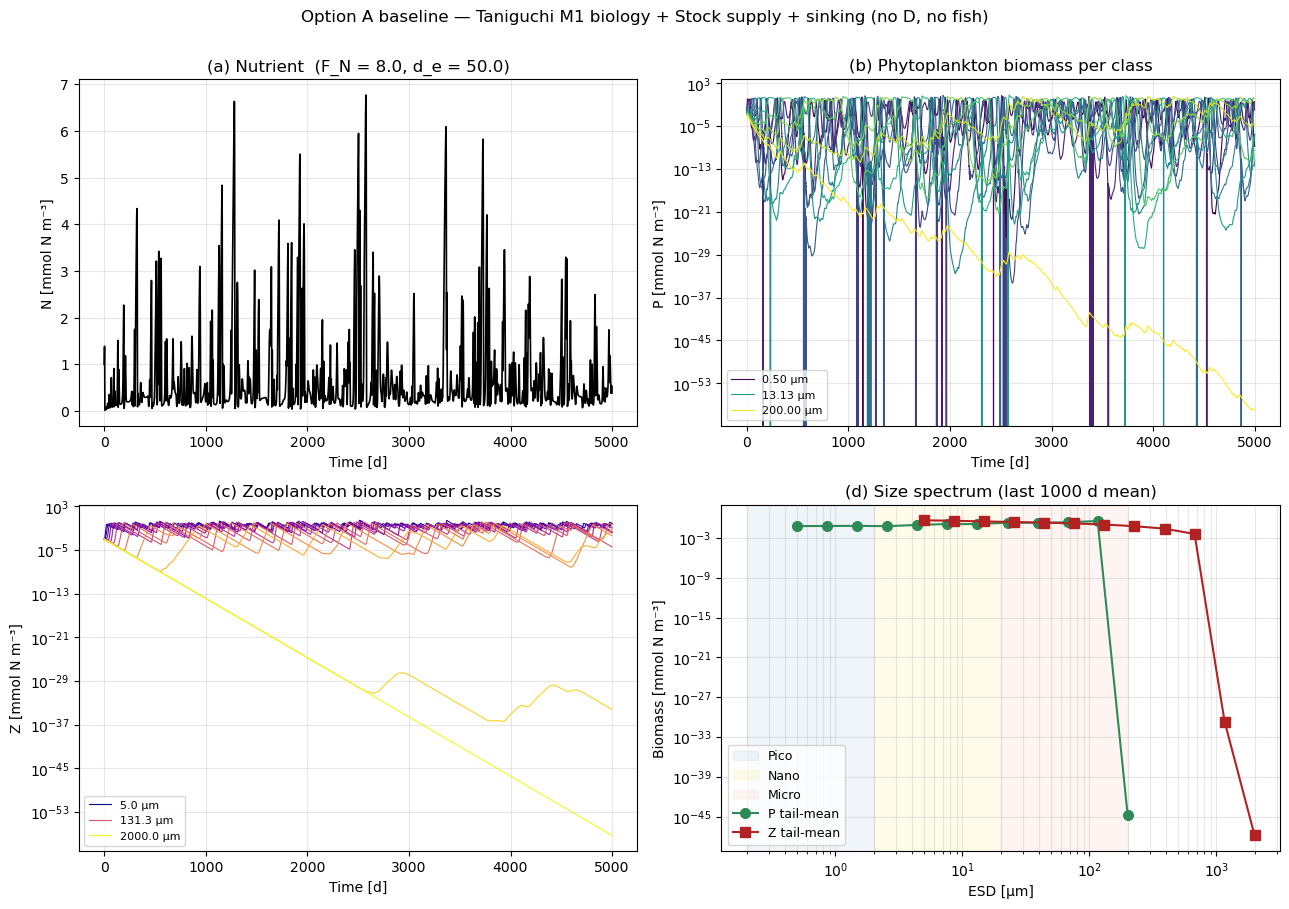

In [2]:
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import cariaco_baseline_setups as cbs
import run_baseline_diagnostic as rbd
importlib.reload(cbs); importlib.reload(rbd)

out = rbd.run_setup(cbs.model_baseline, cbs.model_setup_baseline,
                    input_vars_override={'Supply': {'FN': 8.0}})
state = rbd.extract_state(out)
metrics = rbd.compute_metrics(state, cbs.phyto_esd, cbs.zoo_esd)

print(f'NBSS slope  : {metrics["nbss_slope"]:+.3f}')
print(f'centroid    : {metrics["centroid"]:+.3f}')
print(f'slope_2pt   : {metrics["slope_2pt"]:+.3f}')
print(f'Pico/Nano/Micro biomass: {metrics["P_bins"]}')

fig = rbd.plot_diagnostic(state, cbs.phyto_esd, cbs.zoo_esd,
                          FN=8.0, de=cbs.DE_DEFAULT,
                          save_path='fig_baseline_FN8_with_slope.png')

=== Baseline ===
  F_N =  0.50  NBSS = +nan  centroid = -0.201  ΣP = 0.100  ΣZ = 0.022
  F_N =  1.82  NBSS = -15.477  centroid = +0.345  ΣP = 0.368  ΣZ = 0.464
  F_N =  3.14  NBSS = -1.027  centroid = +0.710  ΣP = 0.636  ΣZ = 1.588
  F_N =  4.45  NBSS = -0.956  centroid = +0.980  ΣP = 0.874  ΣZ = 1.634
  F_N =  5.77  NBSS = -0.918  centroid = +1.143  ΣP = 1.164  ΣZ = 1.842
  F_N =  7.09  NBSS = -0.907  centroid = +1.161  ΣP = 1.410  ΣZ = 2.091
  F_N =  8.41  NBSS = -0.883  centroid = +1.285  ΣP = 1.681  ΣZ = 2.157
  F_N =  9.73  NBSS = -0.870  centroid = +1.311  ΣP = 1.929  ΣZ = 2.137
  F_N = 11.05  NBSS = -0.888  centroid = +1.195  ΣP = 2.291  ΣZ = 3.015
  F_N = 12.36  NBSS = -0.855  centroid = +1.352  ΣP = 2.454  ΣZ = 2.132
  F_N = 13.68  NBSS = -0.846  centroid = +1.415  ΣP = 2.733  ΣZ = 2.881
  F_N = 15.00  NBSS = -0.850  centroid = +1.340  ΣP = 2.979  ΣZ = 2.473

=== Baseline + fish ===
  F_N =  0.50  NBSS = +nan  centroid = -0.201  ΣP = 0.100  ΣZ = 0.022
  F_N =  1.82  NBSS = -15

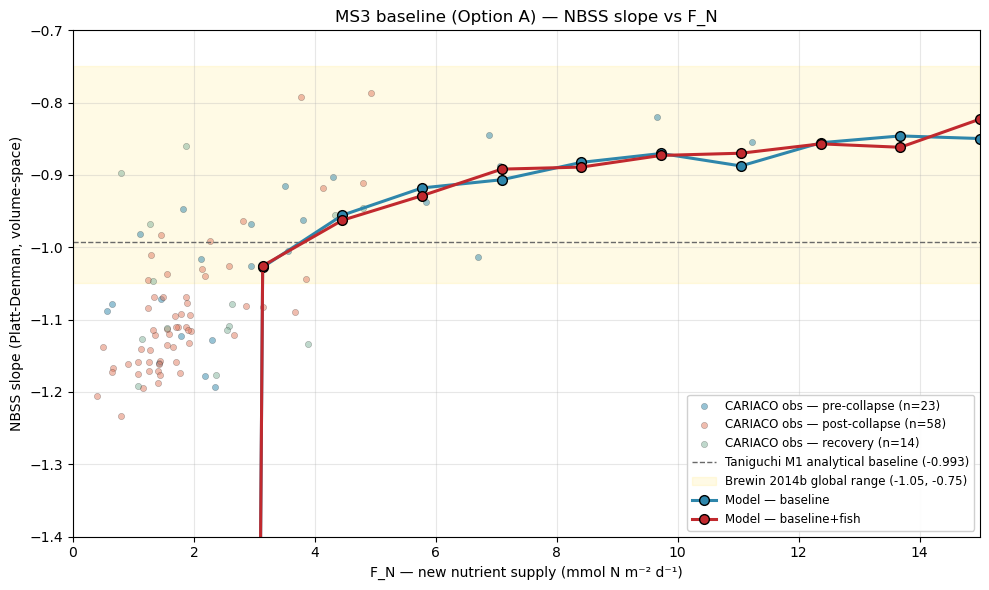

In [3]:
import importlib
import numpy as np
import scan_FN_baseline as scan
import cariaco_baseline_setups as cbs
importlib.reload(cbs); importlib.reload(scan)

fn_values = np.linspace(0.5, 15.0, 12)

print('=== Baseline ===')
scan_base = scan.scan_FN(cbs.model_baseline, cbs.model_setup_baseline,
                         fn_values, cbs.phyto_esd, cbs.zoo_esd)

print('\n=== Baseline + fish ===')
scan_fish = scan.scan_FN(cbs.model_baseline_fish, cbs.model_setup_baseline_fish,
                         fn_values, cbs.phyto_esd, cbs.zoo_esd)

obs_df = scan.load_obs_envelope()      # adjust path if needed; see note below
fig = scan.plot_slope_vs_FN(
    {'baseline': scan_base, 'baseline+fish': scan_fish},
    obs_df=obs_df,
    save_path='fig_slope_vs_FN_baseline_vs_fish.png',
)

In [7]:
import importlib
importlib.reload(rbd)

out = rbd.run_setup(cbs.model_baseline, cbs.model_setup_baseline,
                    input_vars_override={'Supply': {'FN': 2.67}})
df = rbd.obs_comparison_table(out, cbs.phyto_esd, cbs.zoo_esd, regime='all')
print(df.to_string(index=False))

         label        model      obs        ratio  regime_FN  regime_de
  Pico (<2 µm) 1.742967e-01 0.252143 6.912619e-01   2.683444  45.576739
Nano (2-20 µm) 3.005988e-01 0.144697 2.077439e+00   2.683444  45.576739
Micro (>20 µm) 6.258148e-02 0.199765 3.132749e-01   2.683444  45.576739
   Zoo >200 µm 3.439332e-25 0.059377 5.792353e-24   2.683444  45.576739
   Zoo >500 µm 4.626779e-48 0.033023 1.401088e-46   2.683444  45.576739
           NO3 2.236416e-01 1.467052 1.524429e-01   2.683444  45.576739
            PP 1.626198e-01 0.432470 3.760258e-01   2.683444  45.576739
        Export 2.687617e+00 3.182666 8.444545e-01   2.683444  45.576739


In [6]:
list(out.data_vars)

['Core__solver_kwargs',
 'Core__solver_type',
 'Grazing__Imax',
 'Grazing__KsZ',
 'Grazing__gain_Z_value',
 'Grazing__gamma',
 'Grazing__loss_P_value',
 'Grazing__nutrient',
 'Grazing__phyto',
 'Grazing__recycle_to_N_value',
 'Grazing__zoo',
 'Growth__consumer',
 'Growth__halfsat',
 'Growth__mu_max',
 'Growth__resource',
 'Growth__uptake_value',
 'Nutrient__value',
 'Nutrient__value_init',
 'Nutrient__value_label',
 'PhytoLoss__mortality_value',
 'PhytoLoss__nutrient',
 'PhytoLoss__population',
 'PhytoLoss__rate',
 'PhytoLoss__recycle_to_N_value',
 'PhytoSinking__population',
 'PhytoSinking__sinking_value',
 'PhytoSinking__w_over_de',
 'Phytoplankton__biomass',
 'Phytoplankton__biomass_init',
 'Phytoplankton__biomass_label',
 'Phytoplankton__phyto_esd_index',
 'Phytoplankton__phyto_esd_label',
 'Supply__FN',
 'Supply__de',
 'Supply__input_value',
 'Supply__var',
 'Time__time_input',
 'ZooLoss__mortality_value',
 'ZooLoss__nutrient',
 'ZooLoss__population',
 'ZooLoss__rate',
 'ZooLoss__

=== Type III baseline ===
  F_N =  0.50  NBSS = +nan  centroid = -0.201  ΣP = 0.100  ΣZ = 0.022
  F_N =  1.82  NBSS = -15.477  centroid = +0.345  ΣP = 0.368  ΣZ = 0.464
  F_N =  3.14  NBSS = -1.027  centroid = +0.710  ΣP = 0.636  ΣZ = 1.588
  F_N =  4.45  NBSS = -0.956  centroid = +0.980  ΣP = 0.874  ΣZ = 1.634
  F_N =  5.77  NBSS = -0.918  centroid = +1.143  ΣP = 1.164  ΣZ = 1.842
  F_N =  7.09  NBSS = -0.907  centroid = +1.161  ΣP = 1.410  ΣZ = 2.091
  F_N =  8.41  NBSS = -0.883  centroid = +1.285  ΣP = 1.681  ΣZ = 2.157
  F_N =  9.73  NBSS = -0.870  centroid = +1.311  ΣP = 1.929  ΣZ = 2.137
  F_N = 11.05  NBSS = -0.888  centroid = +1.195  ΣP = 2.291  ΣZ = 3.015
  F_N = 12.36  NBSS = -0.855  centroid = +1.352  ΣP = 2.454  ΣZ = 2.132
  F_N = 13.68  NBSS = -0.846  centroid = +1.415  ΣP = 2.733  ΣZ = 2.881
  F_N = 15.00  NBSS = -0.850  centroid = +1.340  ΣP = 2.979  ΣZ = 2.473
Saved figure to: fig_slope_vs_FN_with_typeIII.png


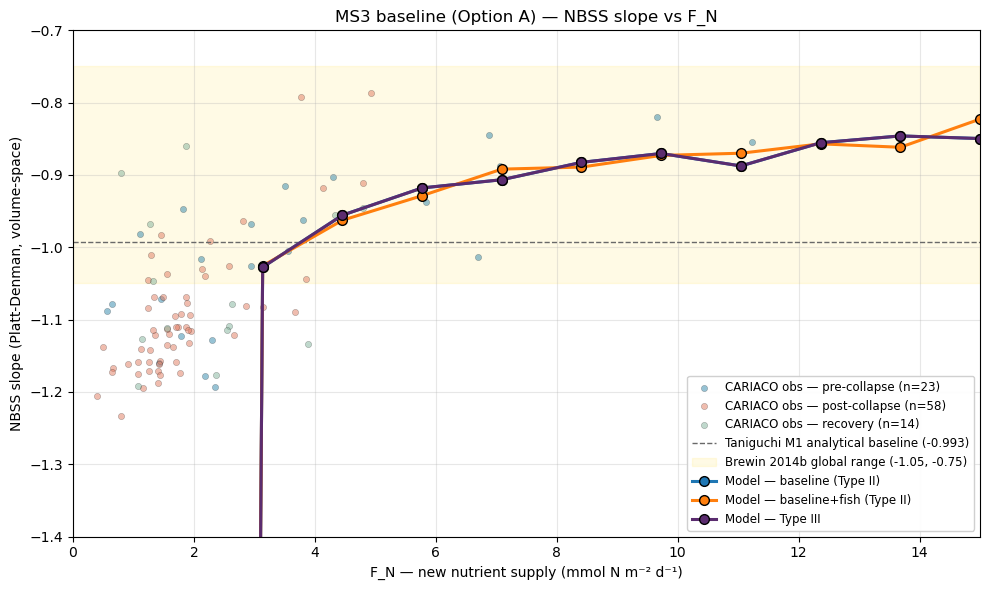

In [4]:
# Edit the setup file: 'Grazing': MatchedGrazing_TypeII → MatchedGrazing_TypeIII
# Then reload and re-run the scan; add the new curve to the plot.
import importlib
importlib.reload(cbs); importlib.reload(scan)

print('=== Type III baseline ===')
scan_t3 = scan.scan_FN(cbs.model_baseline, cbs.model_setup_baseline,
                       fn_values, cbs.phyto_esd, cbs.zoo_esd)

fig = scan.plot_slope_vs_FN(
    {'baseline (Type II)': scan_base,
     'baseline+fish (Type II)': scan_fish,
     'Type III': scan_t3},
    obs_df=obs_df,
    save_path='fig_slope_vs_FN_with_typeIII.png',
)

No-fish baseline at F_N=8.0:
  NBSS slope = -0.887
  centroid   = +1.266
  ΣZ         = 1.983
  rate=0.010  e_F=0.00  NBSS=-0.951  centroid=+0.982  ΣP=1.445  ΣZ=1.494
  rate=0.010  e_F=0.50  NBSS=-0.900  centroid=+1.186  ΣP=1.567  ΣZ=2.188


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:141: UserWarning: Instability event triggered at t=1930 on P[1] = -0.0034. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  rate=0.010  e_F=1.00  NBSS=+nan  centroid=+nan  ΣP=  nan  ΣZ=  nan
  rate=0.010  e_F=1.50  NBSS=-0.899  centroid=+1.166  ΣP=1.603  ΣZ=2.411
  rate=0.010  e_F=2.00  NBSS=-0.877  centroid=+1.337  ΣP=1.587  ΣZ=1.924
  rate=0.010  e_F=2.50  NBSS=-0.890  centroid=+1.237  ΣP=1.580  ΣZ=2.272
  rate=0.208  e_F=0.00  NBSS=-25.626  centroid=-0.201  ΣP=1.436  ΣZ=0.079
  rate=0.208  e_F=0.50  NBSS=-1.092  centroid=+0.645  ΣP=1.398  ΣZ=1.058
  rate=0.208  e_F=1.00  NBSS=-0.908  centroid=+1.115  ΣP=1.569  ΣZ=1.339
  rate=0.208  e_F=1.50  NBSS=-0.890  centroid=+1.263  ΣP=1.574  ΣZ=1.556
  rate=0.208  e_F=2.00  NBSS=-0.884  centroid=+1.268  ΣP=1.585  ΣZ=1.681
  rate=0.208  e_F=2.50  NBSS=-0.883  centroid=+1.274  ΣP=1.616  ΣZ=1.773
  rate=0.406  e_F=0.00  NBSS=+nan  centroid=-0.201  ΣP=1.498  ΣZ=0.025
  rate=0.406  e_F=0.50  NBSS=-10.310  centroid=+0.495  ΣP=1.334  ΣZ=0.788
  rate=0.406  e_F=1.00  NBSS=-0.939  centroid=+0.970  ΣP=1.523  ΣZ=1.345
  rate=0.406  e_F=1.50  NBSS=-0.903  centroid=+1.197  Σ

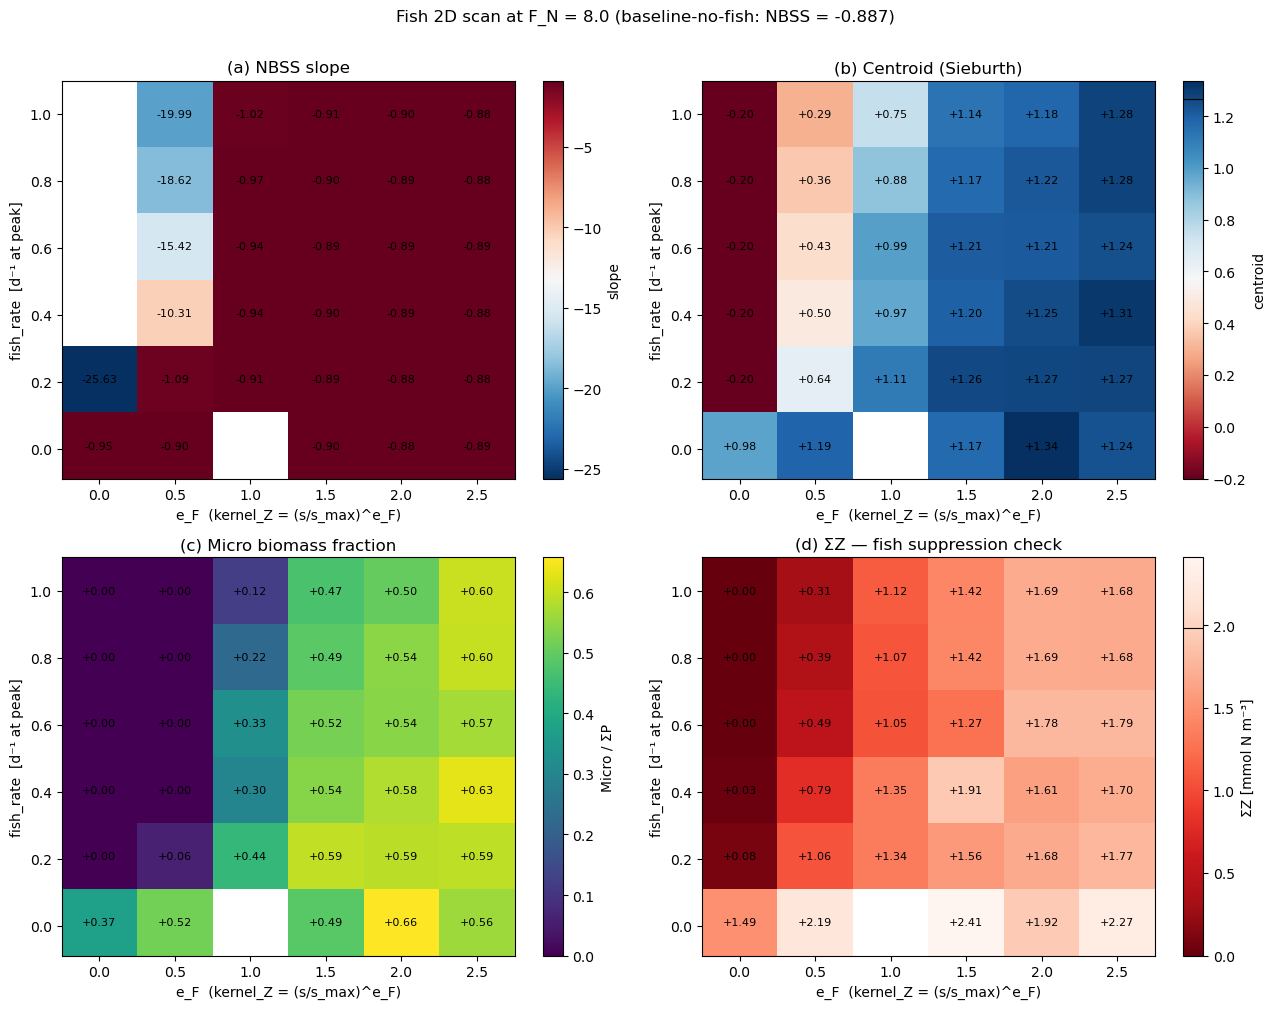

In [8]:
import importlib
import numpy as np
import scan_FN_baseline as scan
import cariaco_baseline_setups as cbs
import run_baseline_diagnostic as rbd
importlib.reload(cbs); importlib.reload(rbd); importlib.reload(scan)

FIXED_FN = 8.0     # where baseline reaches bloom-tail, meso-zoo alive

# --- Reference: baseline NBSS at this F_N with no fish at all -------------
out_base = rbd.run_setup(
    cbs.model_baseline, cbs.model_setup_baseline,
    input_vars_override={'Supply': {'FN': FIXED_FN}},
)
state_base = rbd.extract_state(out_base)
m_base     = rbd.compute_metrics(state_base, cbs.phyto_esd, cbs.zoo_esd)
s_base     = rbd.summarise_tail(state_base)
print(f'No-fish baseline at F_N={FIXED_FN}:')
print(f'  NBSS slope = {m_base["nbss_slope"]:+.3f}')
print(f'  centroid   = {m_base["centroid"]:+.3f}')
print(f'  ΣZ         = {s_base["sumZ"]:.3f}')

# --- 2D scan: 6 fish_rates × 6 e_Fs -------------------------------------
fish_rates = np.linspace(0.01, 1.0,  6)   # [0.01, 0.21, 0.41, 0.60, 0.80, 1.00]
e_Fs       = np.linspace(0.0,  2.5,  6)   # [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
# e_F = 0 is the sentinel: uniform kernel_Z = 1 on all Z classes

scan_2d = scan.scan_fish_2d(
    cbs.model_baseline_fish, cbs.model_setup_baseline_fish,
    fish_rates, e_Fs, cbs.phyto_esd, cbs.zoo_esd,
    fixed_FN=FIXED_FN,
)

fig = scan.plot_fish_2d_heatmaps(
    scan_2d,
    baseline_nbss=m_base['nbss_slope'],
    baseline_centroid=m_base['centroid'],
    baseline_sumZ=s_base['sumZ'],
    save_path=f'fig_fish_2d_FN{FIXED_FN}.png',
)


--- Type II ---


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide


  F_N= 1.00  max CV_P= 1.065  max CV_Z= 0.902  ΣP=0.201  ΣZ=0.169
  F_N= 3.00  max CV_P= 2.121  max CV_Z= 1.204  ΣP=0.589  ΣZ=1.558
  F_N= 5.00  max CV_P= 2.617  max CV_Z= 2.834  ΣP=0.998  ΣZ=1.762
  F_N= 7.00  max CV_P= 4.011  max CV_Z= 2.245  ΣP=1.387  ΣZ=2.231
  F_N= 9.00  max CV_P= 6.347  max CV_Z= 2.729  ΣP=1.791  ΣZ=2.637
  F_N=11.00  max CV_P= 3.469  max CV_Z= 3.391  ΣP=2.211  ΣZ=2.123
  F_N=13.00  max CV_P= 5.484  max CV_Z= 2.878  ΣP=2.570  ΣZ=2.416
  F_N=15.00  max CV_P= 5.603  max CV_Z= 3.596  ΣP=2.979  ΣZ=2.473

--- Type III ---


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide


  F_N= 1.00  max CV_P= 0.000  max CV_Z=   nan  ΣP=0.200  ΣZ=0.000


...

  F_N= 7.00  max CV_P= 0.000  max CV_Z= 0.000  ΣP=1.400  ΣZ=0.740


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide


  F_N= 9.00  max CV_P= 0.000  max CV_Z= 0.000  ΣP=1.800  ΣZ=1.571


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide


  F_N=11.00  max CV_P= 0.000  max CV_Z= 0.083  ΣP=2.193  ΣZ=5.289
  F_N=13.00  max CV_P= 0.037  max CV_Z= 0.013  ΣP=2.599  ΣZ=6.465
  F_N=15.00  max CV_P= 0.375  max CV_Z= 0.146  ΣP=3.011  ΣZ=11.740
Saved figure to: fig_stability_vs_FN_t2_vs_t3.png


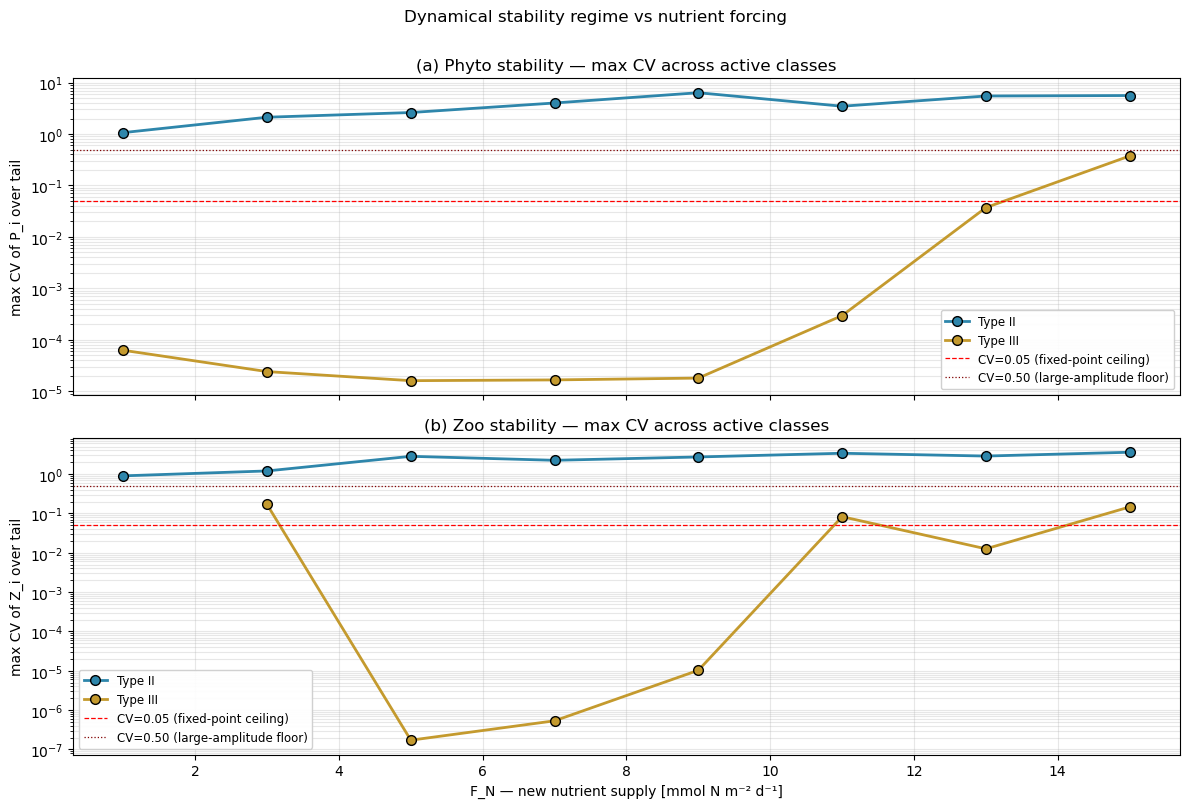

In [10]:
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import xso
import cariaco_baseline_setups as cbs
import run_baseline_diagnostic as rbd
import scan_FN_baseline as scan
importlib.reload(cbs); importlib.reload(rbd); importlib.reload(scan)

from cariaco_baseline_comps import (
    Nutrient, PhytoSizeSpectrum, ZooSizeSpectrum,
    StockNutrientSupply, MonodGrowth_NP,
    PhytoLinearLoss_recycled, ZooLinearLoss_recycled,
    MatchedGrazing_TypeII, MatchedGrazing_TypeIII,
    PhytoSinking_export,
)


# --- Build Type III variant inline (same as before) -----------------------
model_baseline_t3 = xso.create({
    'Nutrient':      Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,
    'Zooplankton':   ZooSizeSpectrum,
    'Supply':        StockNutrientSupply,
    'Growth':        MonodGrowth_NP,
    'Grazing':       MatchedGrazing_TypeIII,
    'PhytoLoss':     PhytoLinearLoss_recycled,
    'ZooLoss':       ZooLinearLoss_recycled,
    'PhytoSinking':  PhytoSinking_export,
})
input_vars_t3 = {
    'Nutrient':      {'value_label': 'N', 'value_init': cbs.N_INIT},
    'Phytoplankton': {'biomass_label': 'P', 'biomass_init': cbs.phyto_init,
                      'phyto_esd_index': cbs.phyto_esd.tolist(),
                      'phyto_esd_label': 'phyto_esd'},
    'Zooplankton':   {'biomass_label': 'Z', 'biomass_init': cbs.zoo_init,
                      'zoo_esd_index': cbs.zoo_esd.tolist(),
                      'zoo_esd_label': 'zoo_esd'},
    'Supply':        {'var': 'N', 'FN': cbs.FN_DEFAULT, 'de': cbs.DE_DEFAULT},
    'Growth':        {'resource': 'N', 'consumer': 'P',
                      'mu_max': cbs.mu_max_arr, 'halfsat': cbs.ks_arr},
    'Grazing':       {'phyto': 'P', 'zoo': 'Z', 'nutrient': 'N',
                      'Imax': cbs.Imax_arr, 'KsZ': cbs.KsZ_arr,
                      'gamma': cbs.GAMMA_VAL},
    'PhytoLoss':     {'population': 'P', 'nutrient': 'N', 'rate': cbs.lambda_arr},
    'ZooLoss':       {'population': 'Z', 'nutrient': 'N', 'rate': cbs.delta_arr},
    'PhytoSinking':  {'population': 'P', 'w_over_de': cbs.W_OVER_DE},
}
setup_baseline_t3 = xso.setup(
    solver='solve_ivp', model=model_baseline_t3,
    time=cbs.ivp_time_array, input_vars=input_vars_t3,
    solver_kwargs=cbs.IVP_SOLVER_KWARGS,
)


# --- Multi-F_N stability scan --------------------------------------------
variants = {
    'Type II':  (cbs.model_baseline,    cbs.model_setup_baseline),
    'Type III': (model_baseline_t3,     setup_baseline_t3),
}
fn_values = np.linspace(1.0, 15.0, 8)    # 8 points across the Cariaco range

stab = scan.scan_FN_stability(
    variants, fn_values, cbs.phyto_esd, cbs.zoo_esd,
)

fig_cv = scan.plot_stability_vs_FN(
    stab, save_path='fig_stability_vs_FN_t2_vs_t3.png',
)


--- Stability summary at F_N = 1.0 ---
Type II:
  P: large-amplitude / chaos (max CV = 1.065)
  Z: large-amplitude / chaos (max CV = 0.902)
Type III:
  P: fixed point (max CV = 0.000)
  Z: no alive classes


/Users/aoop/Documents/GitHub/Research/SSMCariaco/parameter_scan/baseline/run_baseline_diagnostic.py:329: RuntimeWarning: invalid value encountered in divide


Saved figure to: fig_dyn_t2_vs_t3_FN1.0.png


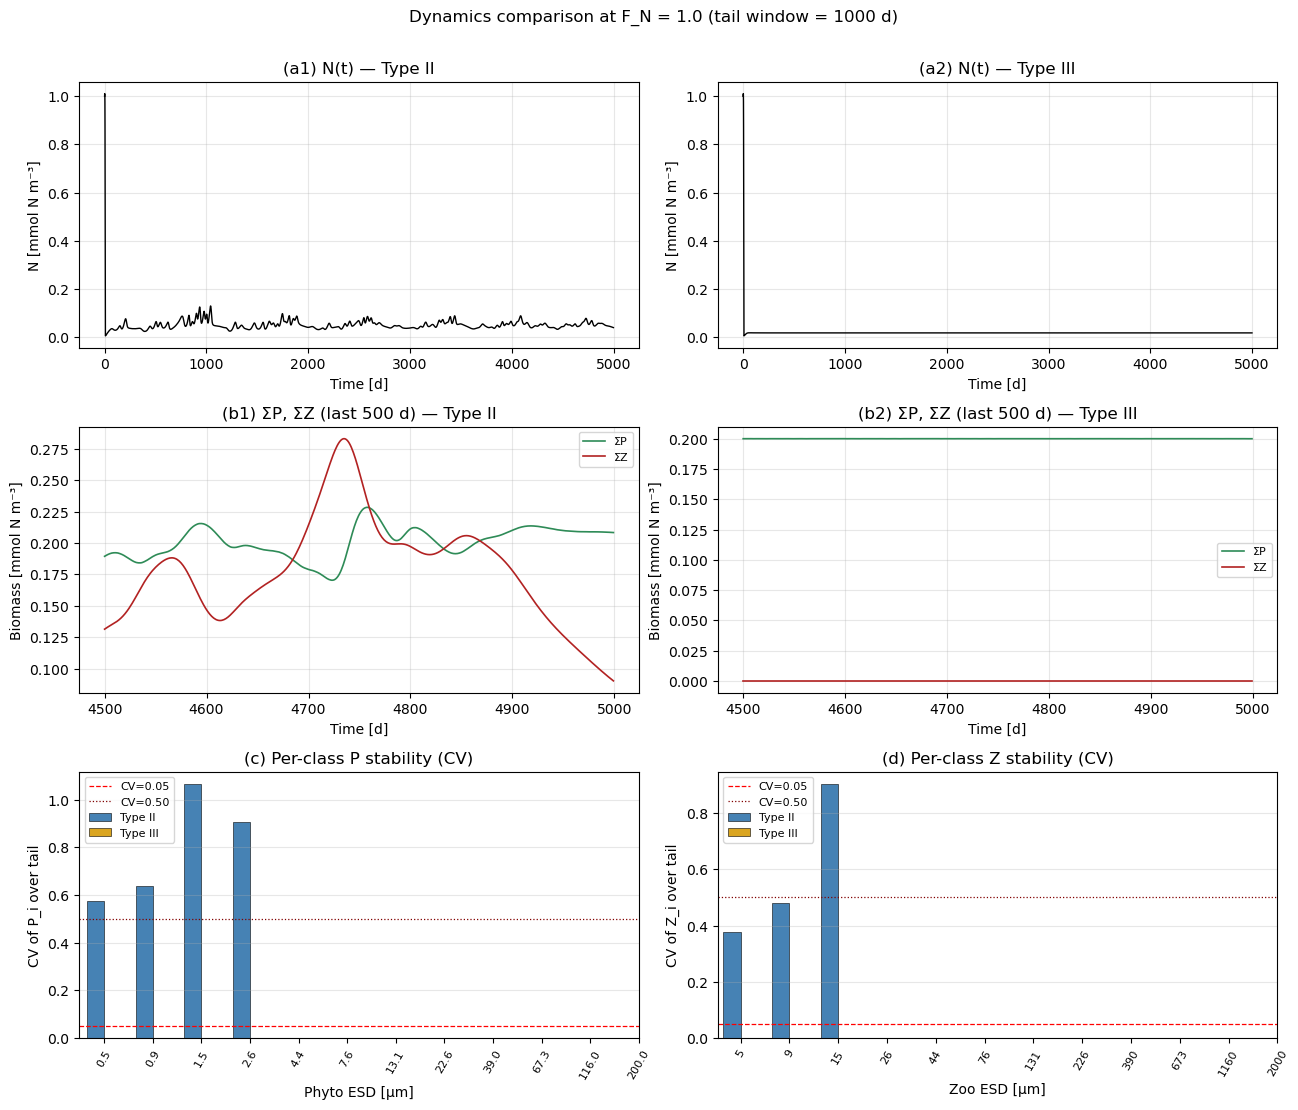

In [12]:
FIXED_FN = 1.0

out_t2 = rbd.run_setup(cbs.model_baseline, cbs.model_setup_baseline,
                       input_vars_override={'Supply': {'FN': FIXED_FN}})
out_t3 = rbd.run_setup(model_baseline_t3, setup_baseline_t3,
                       input_vars_override={'Supply': {'FN': FIXED_FN}})
state_t2 = rbd.extract_state(out_t2)
state_t3 = rbd.extract_state(out_t3)

print(f'\n--- Stability summary at F_N = {FIXED_FN} ---')
print('Type II:')
s_t2 = rbd.stability_summary(state_t2)
print('Type III:')
s_t3 = rbd.stability_summary(state_t3)

fig_pair = rbd.plot_dynamics_compare_pair(
    state_t2, state_t3, 'Type II', 'Type III',
    cbs.phyto_esd, cbs.zoo_esd, fn_value=FIXED_FN,
    save_path=f'fig_dyn_t2_vs_t3_FN{FIXED_FN}.png',
)